In [ ]:

import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Fetch Data
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2026-01-01")
data.columns = data.columns.get_level_values(0) if isinstance(data.columns, pd.MultiIndex) else data.columns

# --- STATIONARY FEATURE ENGINEERING ---

# Daily Return (Percentage change instead of raw price)
data['Daily_Return'] = data['Close'].pct_change()

# Relative Moving Averages (Percentage distance from the close price)
data['SMA_14_Pct'] = (data['Close'] - data['Close'].rolling(window=14).mean()) / data['Close']
data['SMA_50_Pct'] = (data['Close'] - data['Close'].rolling(window=50).mean()) / data['Close']

# RSI (Already stationary because it stays between 0 and 100)
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / (loss + 1e-9)  # Added small value to avoid division by zero
data['RSI'] = 100 - (100 / (1 + rs))

# MACD relative to Close price
exp1 = data['Close'].ewm(span=12, adjust=False).mean()
exp2 = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD_Relative'] = (exp1 - exp2) / data['Close']

# Bollinger Bands %B (Where price sits relative to the bands: 1 = Upper Band, 0 = Lower Band)
ma20 = data['Close'].rolling(window=20).mean()
sd20 = data['Close'].rolling(window=20).std()
upper_band = ma20 + (sd20 * 2)
lower_band = ma20 - (sd20 * 2)
data['Bollinger_PctB'] = (data['Close'] - lower_band) / (upper_band - lower_band + 1e-9)

# Target: Is the price 5 days from now higher?
data['Target'] = np.where(data['Close'].shift(-5) > data['Close'], 1, 0)

data.dropna(inplace=True)

# --- ENGINE MODEL TRAINING ---

# Notice we DO NOT include raw 'Close' price anymore!
stationary_features = ['Daily_Return', 'SMA_14_Pct', 'SMA_50_Pct', 'RSI', 'MACD_Relative', 'Bollinger_PctB']
X = data[stationary_features]
y = data['Target']

# Split Data (Chronological)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Tuned Random Forest Classifier
model = RandomForestClassifier(n_estimators=200, max_depth=4, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
print(f"--- Stationary Model Strategy Evaluation Summary ---")
print(f"Prediction Target Accuracy Score: {accuracy_score(y_test, predictions):.2%}\n")
print(classification_report(y_test, predictions))

/tmp/ipykernel_5455/1773625559.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


--- Stationary Model Strategy Evaluation Summary ---
Prediction Target Accuracy Score: 51.37%

              precision    recall  f1-score   support

           0       0.40      0.20      0.27       129
           1       0.55      0.76      0.64       163

    accuracy                           0.51       292
   macro avg       0.47      0.48      0.45       292
weighted avg       0.48      0.51      0.47       292



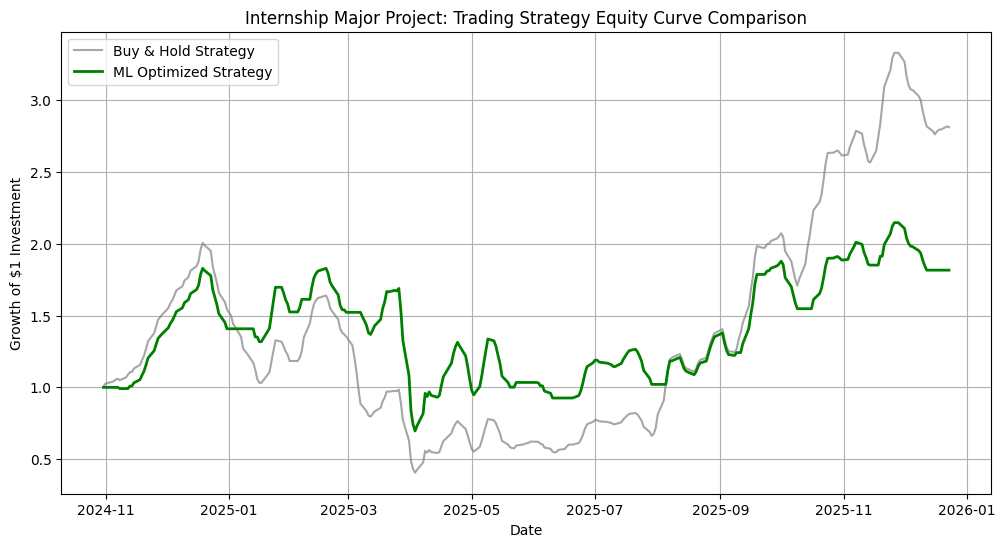

--- Final Strategy Performance Metrics ---
Buy & Hold Total Return: 181.23%
ML Strategy Total Return: 81.65%


In [ ]:
# --- FINANCIAL BACKTESTING ENGINE ---

# 1. Create a dataframe for the test period
backtest_df = X_test.copy()
backtest_df['Actual_Next_Close_Return'] = data['Close'].pct_change(5).shift(-5).loc[X_test.index]
backtest_df['Predicted_Signal'] = predictions

# 2. Calculate Strategy Returns
# If model predicts 1, we get the next 5-day return. If 0, we get 0% return (cash).
backtest_df['Strategy_Return'] = np.where(backtest_df['Predicted_Signal'] == 1,
                                          backtest_df['Actual_Next_Close_Return'],
                                          0)

# Clean up any residual NaN values from the lookahead shift at the very end
backtest_df.dropna(inplace=True)

# 3. Calculate Cumulative Wealth (Assuming starting with $1.00)
backtest_df['Market_Cumulative'] = (1 + backtest_df['Actual_Next_Close_Return']).cumprod()
backtest_df['Strategy_Cumulative'] = (1 + backtest_df['Strategy_Return']).cumprod()

# 4. Plot the Performance (Equity Curve)
plt.figure(figsize=(12, 6))
plt.plot(backtest_df.index, backtest_df['Market_Cumulative'], label='Buy & Hold Strategy', color='gray', alpha=0.7)
plt.plot(backtest_df.index, backtest_df['Strategy_Cumulative'], label='ML Optimized Strategy', color='green', linewidth=2)

plt.title("Internship Major Project: Trading Strategy Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True)
plt.show()

# 5. Print Final PnL Metrics
final_market = (backtest_df['Market_Cumulative'].iloc[-1] - 1) * 100
final_strategy = (backtest_df['Strategy_Cumulative'].iloc[-1] - 1) * 100
print(f"--- Final Strategy Performance Metrics ---")
print(f"Buy & Hold Total Return: {final_market:.2f}%")
print(f"ML Strategy Total Return: {final_strategy:.2f}%")